In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

In [ ]:
cell_name = 'ENCFF035CWS'
pred = pd.read_csv(f'shift_10000_Expression_dataset_v1_GRCh38_csv dataset_pred.csv')[['gene_id', f'{cell_name}']]
gt = pd.read_csv(f'Expression_dataset_v1_GRCh38_csv dataset_true.csv')[['gene_id', f'{cell_name}']]

pred.head()
gt.head()


,gene_id,ENCFF035CWS
0,ENSG00000001617.11,-1.139434
1,ENSG00000002016.17,0.215111
2,ENSG00000002549.12,0.947789
3,ENSG00000002587.9,-2.207275
4,ENSG00000003393.14,0.173953


In [ ]:
data = pd.merge(pred.rename(columns={f'{cell_name}': 'pred'}), gt.rename(columns={f'{cell_name}': 'gt'}), on='gene_id', how='inner', validate='one_to_one')
data

,gene_id,pred,gt
0,ENSG00000001617.11,-0.102686,-1.139434
1,ENSG00000002016.17,-1.817357,0.215111
2,ENSG00000002549.12,0.431053,0.947789
3,ENSG00000002587.9,-3.476290,-2.207275
4,ENSG00000003393.14,0.400441,0.173953
...,...,...,...
3033,ENSG00000285901.1,-1.614552,-1.771957
3034,ENSG00000285971.1,-3.608924,-3.506558
3035,ENSG00000285972.1,-3.548541,-4.605170
3036,ENSG00000285982.1,-3.440194,-4.605170


In [ ]:
gene_info = pd.read_csv('valid_expression_ENCFF035CWS.id.bed', sep='\t', header=None, names=['chrom', 'start', 'end', 'gene_id', 'score', 'strand'])
gene_info.head()
data = pd.merge(data, gene_info, on='gene_id', how='left', validate='one_to_one')
data.head()


,gene_id,pred,gt,chrom,start,end,score,strand
0,ENSG00000001617.11,-0.102686,-1.139434,chr3,50165091,50171235,0,+
1,ENSG00000002016.17,-1.817357,0.215111,chr12,973038,980053,0,-
2,ENSG00000002549.12,0.431053,0.947789,chr4,17587192,17594141,0,+
3,ENSG00000002587.9,-3.476290,-2.207275,chr4,11413467,11419765,0,-
4,ENSG00000003393.14,0.400441,0.173953,chr2,201764184,201771189,0,-


In [ ]:
pd.concat([
	data.groupby('chrom').apply(lambda x: pearsonr(x['pred'], x['gt'])).reset_index(name='pearsonr').sort_values("chrom").set_index("chrom")	,
	data.groupby('chrom').apply(lambda x: len(x)).reset_index(name='Nsamples').sort_values("chrom").set_index("chrom"),
	data.groupby('chrom').apply(lambda x: x["start"].min()).reset_index(name='start').sort_values("chrom").set_index("chrom"),
	data.groupby('chrom').apply(lambda x: x["end"].max()).reset_index(name='end').sort_values("chrom").set_index("chrom")],
	axis=1
).sort_values("pearsonr", ascending=False)


,pearsonr,Nsamples,start,end
chrom,,,,
chr7,"(0.8547657515271057, 0.014255155087307124)",7,157476231,159134957
chr22,"(0.8050127834679693, 4.126122656566273e-07)",27,16531059,18166602
chr18,"(0.7758947665197415, 2.7122177572748558e-08)",36,61344273,66594138
chr13,"(0.7117687871641083, 1.031778049733534e-05)",30,49230338,52149861
chr10,"(0.7064343819579945, 1.3315758980500973e-17)",108,72903581,87112685
chr17,"(0.6419440860175926, 1.6079596179386083e-09)",71,16475110,20201783
chr4,"(0.6372882331580123, 1.0620044924090425e-22)",187,1560284,31523377
chr8,"(0.6076150815168503, 1.1407484662253363e-48)",469,55889813,145068682
chr5,"(0.6033530898100599, 0.006238777045420984)",19,173473500,175002626


Text(0.5, 1.0, 'ENCFF035CWS Pearson Correlation: 0.59')

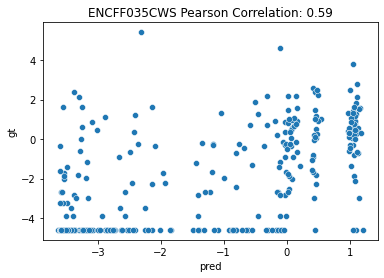

In [7]:
sns.scatterplot(x='pred', y='gt', data=data[::10])
plt.title(f'{cell_name} Pearson Correlation: {pearsonr(data["pred"], data["gt"])[0]:.2f}')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


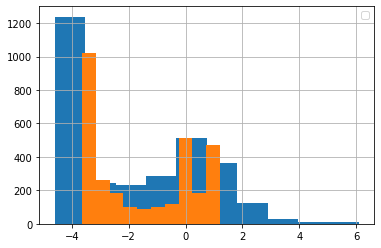

In [8]:
data["gt"].hist()
data["pred"].hist()
plt.legend()


In [9]:
# is there any correlatoin between TPM and gene length?
genes_metadata = pd.read_csv("../datasets/data/genomes/hg38/hg38_genes_split.csv").query("split == 'valid'")
genes_metadata.head()

,chrom,start,end,transcript_id,gene_strand,gene_id,gene_name,chromosome,gene_start,gene_end,transcript_name,transcript_start,transcript_end,TSS,TES,gene_id_unversioned,split
21002,chr2,52910020,52910020,ENST00000443237.1,-,ENSG00000228033.5,AC010967.1,chr2,52722677,52910020,AC010967.1-202,52722677,52910020,52910020,52722677,ENSG00000228033,valid
21003,chr2,52864235,52864235,ENST00000418451.1,+,ENSG00000232604.1,AC010967.2,chr2,52864235,52866631,AC010967.2-201,52864235,52866631,52864235,52866631,ENSG00000232604,valid
21004,chr2,53786942,53786942,ENST00000263634.7,-,ENSG00000115239.21,ASB3,chr2,53532672,53787610,ASB3-201,53669981,53786942,53786942,53669981,ENSG00000115239,valid
21005,chr2,53860160,53860160,ENST00000406625.5,-,ENSG00000270898.5,GPR75-ASB3,chr2,53670293,53860160,GPR75-ASB3-201,53670293,53860160,53860160,53670293,ENSG00000270898,valid
21006,chr2,53767792,53767792,ENST00000295304.4,+,ENSG00000143942.4,CHAC2,chr2,53767792,53775196,CHAC2-201,53767792,53775196,53767792,53775196,ENSG00000143942,valid


In [10]:
assert len(np.intersect1d(data["gene_id"], genes_metadata["gene_id"])) == len(data["gene_id"]) == len(genes_metadata["gene_id"])

In [11]:
genes_metadata["gene_length"] = genes_metadata["gene_end"] - genes_metadata["gene_start"]
genes_metadata

,chrom,start,end,transcript_id,gene_strand,gene_id,gene_name,chromosome,gene_start,gene_end,transcript_name,transcript_start,transcript_end,TSS,TES,gene_id_unversioned,split,gene_length
21002,chr2,52910020,52910020,ENST00000443237.1,-,ENSG00000228033.5,AC010967.1,chr2,52722677,52910020,AC010967.1-202,52722677,52910020,52910020,52722677,ENSG00000228033,valid,187343
21003,chr2,52864235,52864235,ENST00000418451.1,+,ENSG00000232604.1,AC010967.2,chr2,52864235,52866631,AC010967.2-201,52864235,52866631,52864235,52866631,ENSG00000232604,valid,2396
21004,chr2,53786942,53786942,ENST00000263634.7,-,ENSG00000115239.21,ASB3,chr2,53532672,53787610,ASB3-201,53669981,53786942,53786942,53669981,ENSG00000115239,valid,254938
21005,chr2,53860160,53860160,ENST00000406625.5,-,ENSG00000270898.5,GPR75-ASB3,chr2,53670293,53860160,GPR75-ASB3-201,53670293,53860160,53860160,53670293,ENSG00000270898,valid,189867
21006,chr2,53767792,53767792,ENST00000295304.4,+,ENSG00000143942.4,CHAC2,chr2,53767792,53775196,CHAC2-201,53767792,53775196,53767792,53775196,ENSG00000143942,valid,7404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24035,chrX,8927153,8927153,ENST00000650341.1,-,ENSG00000285896.1,AC074281.2,chrX,8897642,8927153,AC074281.2-201,8897642,8927153,8927153,8897642,ENSG00000285896,valid,29511
24036,chrX,9034127,9034127,ENST00000327220.9,-,ENSG00000177138.15,FAM9B,chrX,9024232,9164639,FAM9B-201,9024995,9034127,9034127,9024995,ENSG00000177138,valid,140407
24037,chrX,9249920,9249920,ENST00000432442.1,+,ENSG00000228543.1,AC003684.1,chrX,9249920,9275206,AC003684.1-201,9249920,9275206,9249920,9275206,ENSG00000228543,valid,25286
24038,chrX,9463329,9463329,ENST00000380961.5,+,ENSG00000101849.16,TBL1X,chrX,9463295,9741037,TBL1X-202,9463329,9718862,9463329,9718862,ENSG00000101849,valid,277742


In [12]:
data["gene_length"] = data["gene_id"].map(genes_metadata.set_index("gene_id")["gene_length"])
data.head()

,gene_id,pred,gt,chrom,start,end,score,strand,gene_length
0,ENSG00000001617.11,-0.102686,-1.139434,chr3,50165091,50171235,0,+,34030
1,ENSG00000002016.17,-1.817357,0.215111,chr12,973038,980053,0,-,77976
2,ENSG00000002549.12,0.431053,0.947789,chr4,17587192,17594141,0,+,30780
3,ENSG00000002587.9,-3.476290,-2.207275,chr4,11413467,11419765,0,-,36615
4,ENSG00000003393.14,0.400441,0.173953,chr2,201764184,201771189,0,-,80635


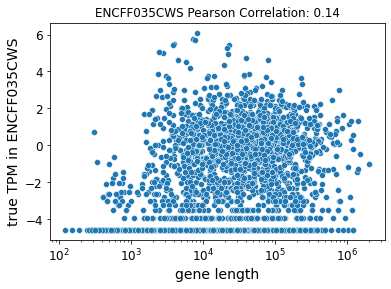

In [13]:
sns.scatterplot(x='gene_length', y='gt', data=data)
plt.title(f'{cell_name} Pearson Correlation: {pearsonr(data["gene_length"], data["gt"])[0]:.2f}')
plt.xlabel('gene length', fontsize=14)
plt.xscale('log')
plt.ylabel(f'true TPM in {cell_name}', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

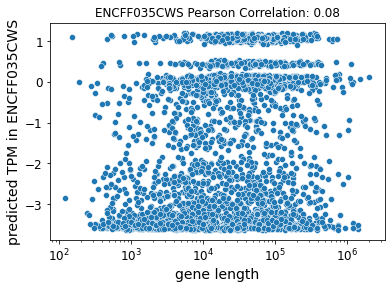

In [14]:
sns.scatterplot(x='gene_length', y='pred', data=data)
plt.title(f'{cell_name} Pearson Correlation: {pearsonr(data["gene_length"], data["pred"])[0]:.2f}')
plt.xlabel('gene length', fontsize=14)
plt.xscale('log')
plt.ylabel(f'predicted TPM in {cell_name}', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [15]:
seqs = pd.read_csv("valid_expression_ENCFF035CWS.seq.bed", sep='\t', header=None, names=['chrom', 'start', 'end', "seq" ,'score', 'strand'])
seqs.head()

,chrom,start,end,seq,score,strand
0,chr2,52874235,52880555,CATGTTTCTGTTCAAGGAGCAATCAAGTATAGGAATAAGGTCACTG...,0,+
1,chr2,53777792,53784641,CCTTTTTATTAAATTTTACCCTTTGTTTTACTAAAAACAATATAAC...,0,+
2,chr2,53797080,53803719,GATGGGGTTTTGCCATGTTGGCCAAGCTGGTCTCGAACTCCTGGTC...,0,+
3,chr2,54125403,54132190,TCAAAAATCCCAAAAATATAATCTGGAAAAAATCATTCAAAGAGTA...,0,+
4,chr2,54092554,54099530,TGCTAGGTGAGGGTGAGGGGAATCTAGAATTGGTAGTGGAAGAGGG...,0,+


In [16]:
data[data.duplicated(subset=["chrom", "start", "end"])]

,gene_id,pred,gt,chrom,start,end,score,strand,gene_length
2854,ENSG00000273045.6,-2.491152,-4.60517,chr2,99151485,99157785,0,+,10002


In [17]:
data.query("chrom == 'chr2' and start==99151485")

,gene_id,pred,gt,chrom,start,end,score,strand,gene_length
2332,ENSG00000241962.9,-2.491152,-1.560648,chr2,99151485,99157785,0,+,181256
2854,ENSG00000273045.6,-2.491152,-4.605170,chr2,99151485,99157785,0,+,10002


In [18]:
seqs.query("chrom == 'chr2' and start==99151485")

,chrom,start,end,seq,score,strand
79,chr2,99151485,99157785,AAGTCCAAGCAATGTGACATCCGTATTTCACAATATTTCTGGTGTA...,0,+
80,chr2,99151485,99157785,AAGTCCAAGCAATGTGACATCCGTATTTCACAATATTTCTGGTGTA...,0,+


In [19]:
_ = data.drop_duplicates(subset=["chrom", "start", "end"]).merge(
	seqs.drop(columns=["score"]).drop_duplicates(subset=["chrom", "start", "end", "strand"]), 
	on=["chrom", "start", "end", "strand"], validate='one_to_one')

<Axes: >

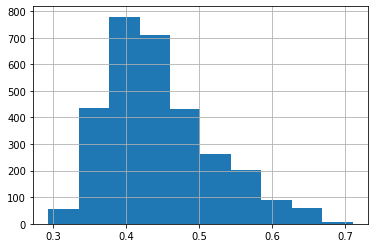

In [20]:
_["gc"] = (_["seq"].str.count("C") + _["seq"].str.count("G")) / (_["seq"].str.len())
_["gc"].hist()

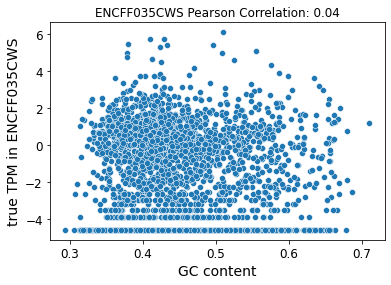

In [21]:
sns.scatterplot(x='gc', y='gt', data=_)
plt.title(f'{cell_name} Pearson Correlation: {pearsonr(_["gc"], _["gt"])[0]:.2f}')
plt.xlabel('GC content', fontsize=14)
plt.ylabel(f'true TPM in {cell_name}', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [22]:
import gffutils
from tqdm import tqdm

VALID_FEATURETYPES = ["gene"]
VALID_GENE_TYPES = ["protein_coding", "lincRNA"]
db = gffutils.FeatureDB("../datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz.db")

selected_genes = []
for gene in tqdm(db.all_features(featuretype=VALID_FEATURETYPES), desc="Processing genes"):
	# Validate gene type
	assert len(gene.attributes["gene_type"]) == 1, f"Gene {gene.attributes['gene_name']} has multiple gene types: {gene.attributes['gene_type']}"
	gene_type = gene.attributes["gene_type"][0]
	if gene_type not in VALID_GENE_TYPES:
		continue
		
	# Get gene information
	gene_start = gene.start
	gene_end = gene.end
	gene_name = gene.attributes["gene_name"][0]
	gene_strand = gene.strand
	
	# Add gene to selected genes
	selected_genes.append({
		"gene_id": gene.id,
		"gene_name": gene_name,
		"chromosome": gene.chrom,
		"gene_start": gene_start,
		"gene_end": gene_end,
		"gene_strand": gene_strand,
		"gene_type": gene_type
	})

# Save results
selected_genes_df = pd.DataFrame(selected_genes)

Processing genes: 58780it [00:09, 6314.30it/s]


In [23]:
data["gene_type"] = data["gene_id"].map(selected_genes_df.set_index("gene_id")["gene_type"])
data.head()

,gene_id,pred,gt,chrom,start,end,score,strand,gene_length,gene_type
0,ENSG00000001617.11,-0.102686,-1.139434,chr3,50165091,50171235,0,+,34030,protein_coding
1,ENSG00000002016.17,-1.817357,0.215111,chr12,973038,980053,0,-,77976,protein_coding
2,ENSG00000002549.12,0.431053,0.947789,chr4,17587192,17594141,0,+,30780,protein_coding
3,ENSG00000002587.9,-3.476290,-2.207275,chr4,11413467,11419765,0,-,36615,protein_coding
4,ENSG00000003393.14,0.400441,0.173953,chr2,201764184,201771189,0,-,80635,protein_coding


<Axes: >

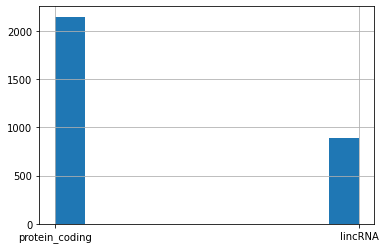

In [24]:
data["gene_type"].hist()

genes > 1e4:  0.6682027649769585
genes > 1e5:  0.18169848584595127


Text(0.5, 1.0, 'all genes')

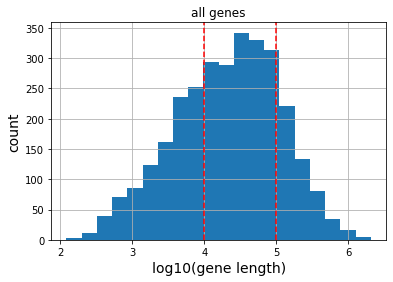

In [25]:
np.log10(data["gene_length"]).hist(bins=20)
plt.xlabel('log10(gene length)', fontsize=14)
print ("genes > 1e4: ", len(data.query("gene_length > 1e4"))/len(data))
print ("genes > 1e5: ", len(data.query("gene_length > 1e5"))/len(data))
plt.axvline(np.log10(1e4), color='red', linestyle='--')
plt.axvline(np.log10(1e5), color='red', linestyle='--')
plt.ylabel('count', fontsize=14)
plt.title("all genes")

Text(0.5, 1.0, 'protein coding genes')

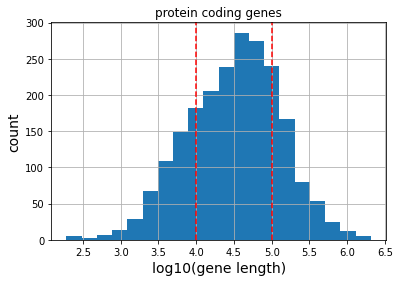

In [26]:
np.log10(data.query("gene_type == 'protein_coding'")["gene_length"]).hist(bins=20)
plt.xlabel('log10(gene length)', fontsize=14)
plt.axvline(np.log10(1e4), color='red', linestyle='--')
plt.axvline(np.log10(1e5), color='red', linestyle='--')
plt.ylabel('count', fontsize=14)
plt.title("protein coding genes")

Text(0.5, 1.0, 'lincRNA genes')

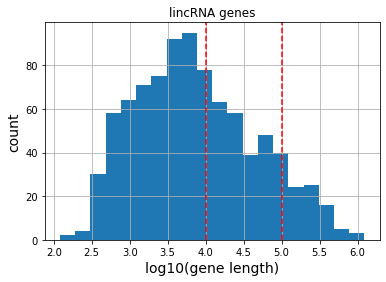

In [36]:
np.log10(data.query("gene_type == 'lincRNA'")["gene_length"]).hist(bins=20)
plt.xlabel('log10(gene length)', fontsize=14)
plt.axvline(np.log10(1e4), color='red', linestyle='--')
plt.axvline(np.log10(1e5), color='red', linestyle='--')
plt.ylabel('count', fontsize=14)
plt.title("lincRNA genes")

In [28]:
print ("Correlation for genes>1e4: ",
	pearsonr(data.query("gene_length > 1e4")["gt"], data.query("gene_length > 1e4")["pred"])[0]
)
print ("Correlation for genes<1e4: ",
	pearsonr(data.query("gene_length < 1e4")["gt"], data.query("gene_length < 1e4")["pred"])[0]
)


Correlation for genes>1e4:  0.6092384411508825
Correlation for genes<1e4:  0.37947269129891836


In [29]:
print ("Correlation for protein coding genes: ",
	pearsonr(data.query("gene_type == 'protein_coding'")["gt"], data.query("gene_type == 'protein_coding'")["pred"])[0]
)
print ("Correlation for lincRNA genes: ",
	pearsonr(data.query("gene_type == 'lincRNA'")["gt"], data.query("gene_type == 'lincRNA'")["pred"])[0]
)


Correlation for protein coding genes:  0.4617037641607732
Correlation for lincRNA genes:  0.139488728411107


Text(0, 0.5, 'true TPM')

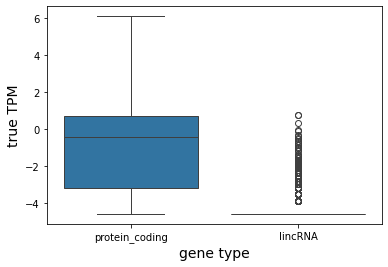

In [30]:
sns.boxplot(x='gene_type', y='gt', data=data)
plt.xlabel('gene type', fontsize=14)
plt.ylabel('true TPM', fontsize=14)

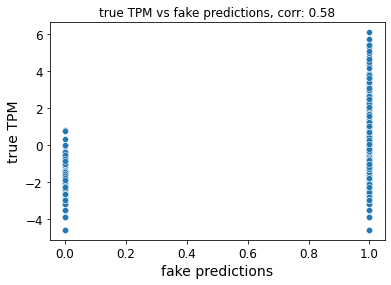

In [31]:
data["fake_predictions"] = data["gene_type"].apply(
	lambda x: 1 if x == "protein_coding" else 0
	)
sns.scatterplot(x='fake_predictions', y='gt', data=data)
plt.title(f"true TPM vs fake predictions, corr: {pearsonr(data['fake_predictions'], data['gt'])[0]:.2f}")
plt.xlabel('fake predictions', fontsize=14)
plt.ylabel('true TPM', fontsize=14)
plt.xticks(fontsize=12)
_ = plt.yticks(fontsize=12)

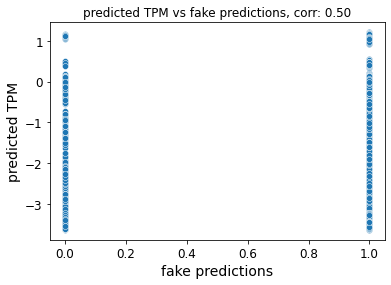

In [32]:
data["fake_predictions"] = data["gene_type"].apply(
	lambda x: 1 if x == "protein_coding" else 0
	)
sns.scatterplot(x='fake_predictions', y='pred', data=data)
plt.title(f"predicted TPM vs fake predictions, corr: {pearsonr(data['fake_predictions'], data['pred'])[0]:.2f}")
plt.xlabel('fake predictions', fontsize=14)
plt.ylabel('predicted TPM', fontsize=14)
plt.xticks(fontsize=12)
_ = plt.yticks(fontsize=12)

Text(0.5, 1.0, 'predicted TPM vs true TPM for protein coding genes')

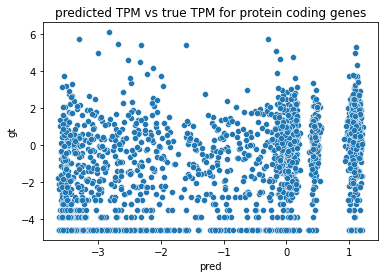

In [33]:
sns.scatterplot(x='pred', y='gt', data=data.query("gene_type == 'protein_coding'"))
plt.title("predicted TPM vs true TPM for protein coding genes")

Text(0.5, 1.0, 'predicted TPM vs true TPM for lincRNA genes')

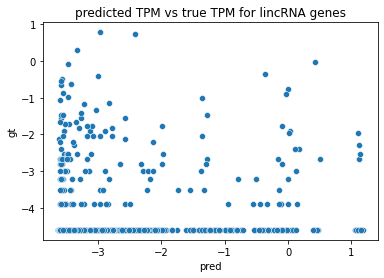

In [34]:
sns.scatterplot(x='pred', y='gt', data=data.query("gene_type == 'lincRNA'"))
plt.title("predicted TPM vs true TPM for lincRNA genes")

Text(0.5, 1.0, 'predicted TPM vs true TPM for all genes')

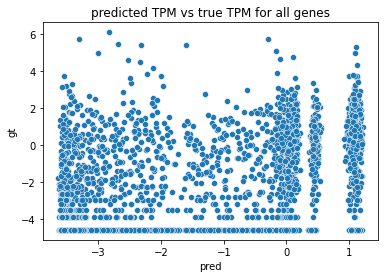

In [35]:
sns.scatterplot(x='pred', y='gt', data=data)
plt.title("predicted TPM vs true TPM for all genes")

